# 🌫️ Air Quality Analysis (Beijing Dataset)

This notebook performs:
- Data loading & merging
- Data cleaning (missing values, duplicates)
- Outlier detection
- Statistical analysis
- Visualization (bar, histogram, line, boxplot)
- Correlation analysis


In [ ]:
# Install required libraries (only needed in Colab)
!pip install pandas matplotlib seaborn

# Import libraries
import pandas as pd
import seaborn as sns
import glob
import matplotlib.pyplot as plt


## 📁 Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving PRSA_Data_Aotizhongxin_20130301-20170228.csv to PRSA_Data_Aotizhongxin_20130301-20170228.csv
Saving PRSA_Data_Changping_20130301-20170228.csv to PRSA_Data_Changping_20130301-20170228.csv
Saving PRSA_Data_Dingling_20130301-20170228.csv to PRSA_Data_Dingling_20130301-20170228.csv
Saving PRSA_Data_Dongsi_20130301-20170228.csv to PRSA_Data_Dongsi_20130301-20170228.csv
Saving PRSA_Data_Guanyuan_20130301-20170228.csv to PRSA_Data_Guanyuan_20130301-20170228.csv
Saving PRSA_Data_Gucheng_20130301-20170228.csv to PRSA_Data_Gucheng_20130301-20170228.csv
Saving PRSA_Data_Huairou_20130301-20170228.csv to PRSA_Data_Huairou_20130301-20170228.csv
Saving PRSA_Data_Nongzhanguan_20130301-20170228.csv to PRSA_Data_Nongzhanguan_20130301-20170228.csv
Saving PRSA_Data_Shunyi_20130301-20170228.csv to PRSA_Data_Shunyi_20130301-20170228.csv
Saving PRSA_Data_Tiantan_20130301-20170228.csv to PRSA_Data_Tiantan_20130301-20170228.csv
Saving PRSA_Data_Wanliu_20130301-20170228.csv to PRSA_Data_Wanliu_20130301-2

In [ ]:
# Or mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📂 Load and Combine CSV Files

In [ ]:
files = glob.glob("/content/*.csv")
print("Files found:", files)

df_list = [pd.read_csv(file) for file in files]
combined_df = pd.concat(df_list, ignore_index=True)
combined_df.head()

Files found: ['/content/PRSA_Data_Gucheng_20130301-20170228.csv', '/content/PRSA_Data_Shunyi_20130301-20170228.csv', '/content/PRSA_Data_Dingling_20130301-20170228.csv', '/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv', '/content/PRSA_Data_Wanshouxigong_20130301-20170228.csv', '/content/PRSA_Data_Changping_20130301-20170228.csv', '/content/PRSA_Data_Tiantan_20130301-20170228.csv', '/content/PRSA_Data_Wanliu_20130301-20170228.csv', '/content/PRSA_Data_Nongzhanguan_20130301-20170228.csv', '/content/PRSA_Data_Dongsi_20130301-20170228.csv', '/content/PRSA_Data_Guanyuan_20130301-20170228.csv', '/content/PRSA_Data_Huairou_20130301-20170228.csv']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


## 🔍 Basic Data Inspection

In [ ]:
print(combined_df.dtypes)
print("Rows:", combined_df.shape[0])
print("Columns:", combined_df.shape[1])
combined_df.info()

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object
Rows: 420768
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 

## ⚠️ Check Missing Values

In [ ]:
print("PM2.5 missing:", combined_df["PM2.5"].isnull().sum())

PM2.5 missing: 8739


## 🧹 Handle Missing Values

In [ ]:
# Create proper datetime column to used as the timestamp
combined_df["datetime"] = pd.to_datetime(
    combined_df[["year", "month", "day", "hour"]]
)
combined_df = combined_df.sort_values("datetime")
combined_df.set_index("datetime", inplace=True)

# Time-based interpolation
combined_df["PM2.5"] = combined_df["PM2.5"].interpolate(method="time")

# Fill edge values
combined_df["PM2.5"] = combined_df["PM2.5"].bfill().ffill()

print("Remaining nulls:", combined_df["PM2.5"].isnull().sum())

Remaining nulls: 0


## 🔁 Check Duplicates

In [ ]:
duplicates = combined_df.duplicated(subset=["year", "month", "day", "hour", "station"])
print("Duplicate records:", duplicates.sum())

Duplicate records: 0


## 🚨 Outlier Detection

In [ ]:
# Interquartile Range Will be used to detect Outliers
Q1 = combined_df["PM2.5"].quantile(0.25)
Q3 = combined_df["PM2.5"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df["PM2.5"] < lower_bound) | (combined_df["PM2.5"] > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower Bound: -116.5
Upper Bound: 247.5
Number of outliers: 19642


## 📊 Statistical Summary

In [ ]:
print("Mean:", combined_df["PM2.5"].mean())
print("Median:", combined_df["PM2.5"].median())
print("Min:", combined_df["PM2.5"].min())
print("Max:", combined_df["PM2.5"].max())
print("Std Dev:", combined_df["PM2.5"].std())

Mean: 79.84951802418435
Median: 55.0
Min: 2.0
Max: 999.0
Std Dev: 81.08368179826495


## 🏙️ Average PM2.5 by Station

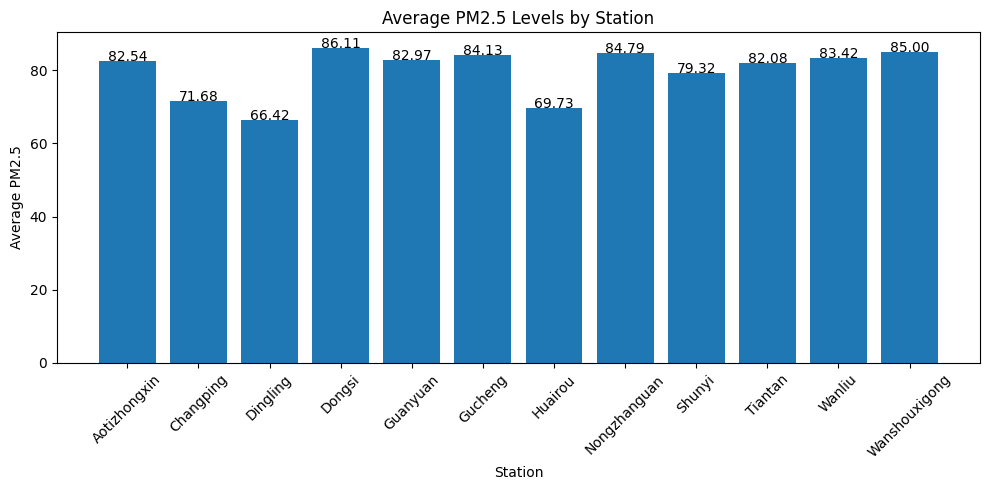

In [ ]:
avg_by_station = combined_df.groupby("station")["PM2.5"].mean()

plt.figure(figsize=(10,5))
bars = plt.bar(avg_by_station.index, avg_by_station.values)

plt.title("Average PM2.5 Levels by Station")
plt.xlabel("Station")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha='center')

plt.tight_layout()
plt.show()

## 📉 Histogram

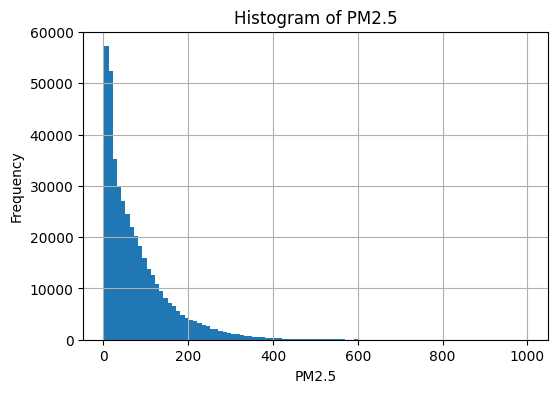

In [ ]:
plt.figure(figsize=(6,4))
combined_df["PM2.5"].hist(bins=100)

plt.title("Histogram of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

## 📈 Weekly Trend

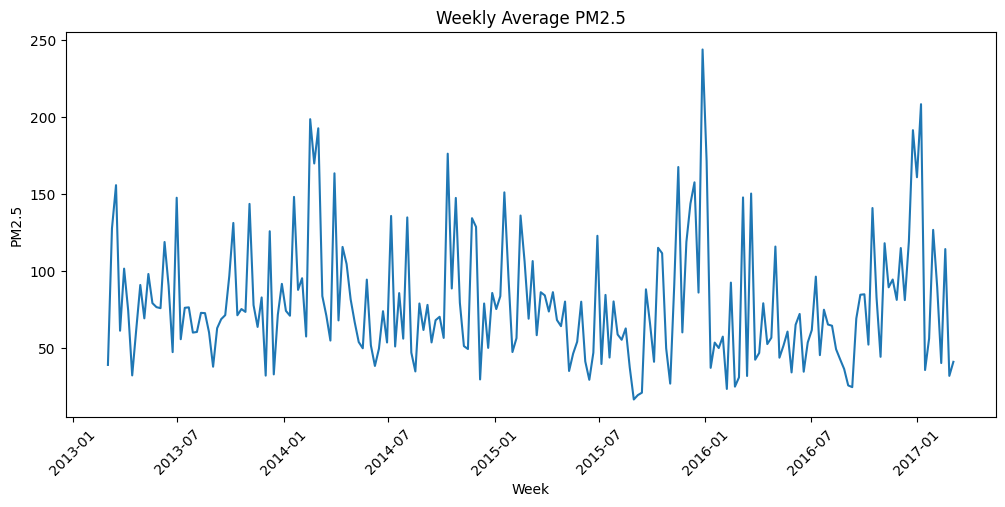

In [ ]:
weekly_avg = combined_df["PM2.5"].resample("W").mean()

plt.figure(figsize=(12,5))
plt.plot(weekly_avg.index, weekly_avg.values)

plt.title("Weekly Average PM2.5")
plt.xlabel("Week")
plt.ylabel("PM2.5")

plt.xticks(rotation=45)
plt.show()

## 📦 Boxplot

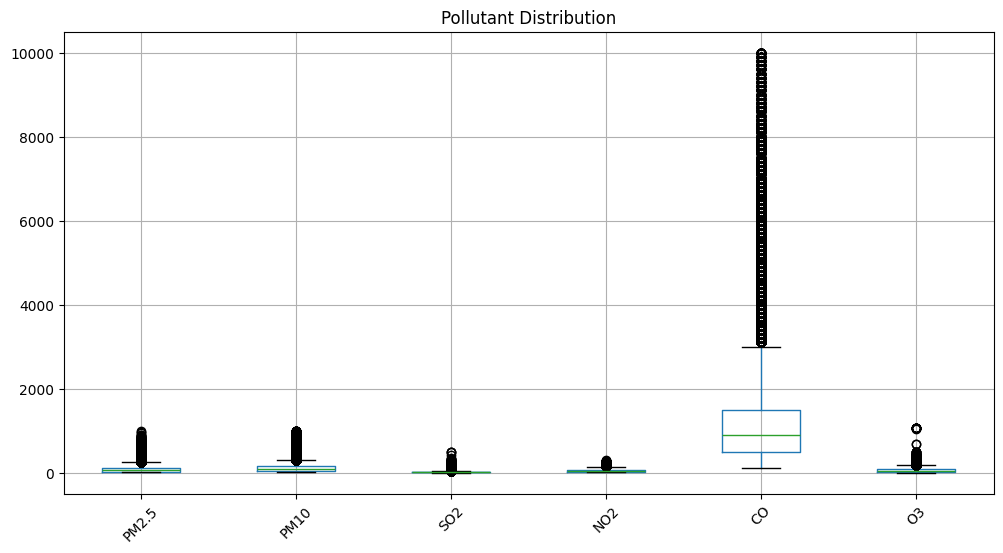

In [ ]:
pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]

plt.figure(figsize=(12,6))
combined_df[pollutants].boxplot()

plt.title("Pollutant Distribution")
plt.xticks(rotation=45)

plt.show()

## 🔗 Correlation Heatmap

          PM2.5      PM10       SO2       NO2        CO        O3      TEMP  \
PM2.5  1.000000  0.882953  0.481213  0.666115  0.789007 -0.148622 -0.131679   
PM10   0.882953  1.000000  0.462651  0.652193  0.702363 -0.111294 -0.096209   
SO2    0.481213  0.462651  1.000000  0.499496  0.535750 -0.165341 -0.321799   
NO2    0.666115  0.652193  0.499496  1.000000  0.705500 -0.471587 -0.278192   
CO     0.789007  0.702363  0.535750  0.705500  1.000000 -0.313012 -0.326237   
O3    -0.148622 -0.111294 -0.165341 -0.471587 -0.313012  1.000000  0.594910   
TEMP  -0.131679 -0.096209 -0.321799 -0.278192 -0.326237  0.594910  1.000000   
PRES   0.019970 -0.017971  0.223236  0.174167  0.188195 -0.445961 -0.813309   
DEWP   0.113640  0.070310 -0.266781 -0.031599 -0.057129  0.312074  0.820118   
RAIN  -0.014458 -0.026519 -0.040241 -0.043785 -0.013342  0.023320  0.037635   
WSPM  -0.272352 -0.183665 -0.108717 -0.400460 -0.297511  0.295743  0.033036   

           PRES      DEWP      RAIN      WSPM  
PM2

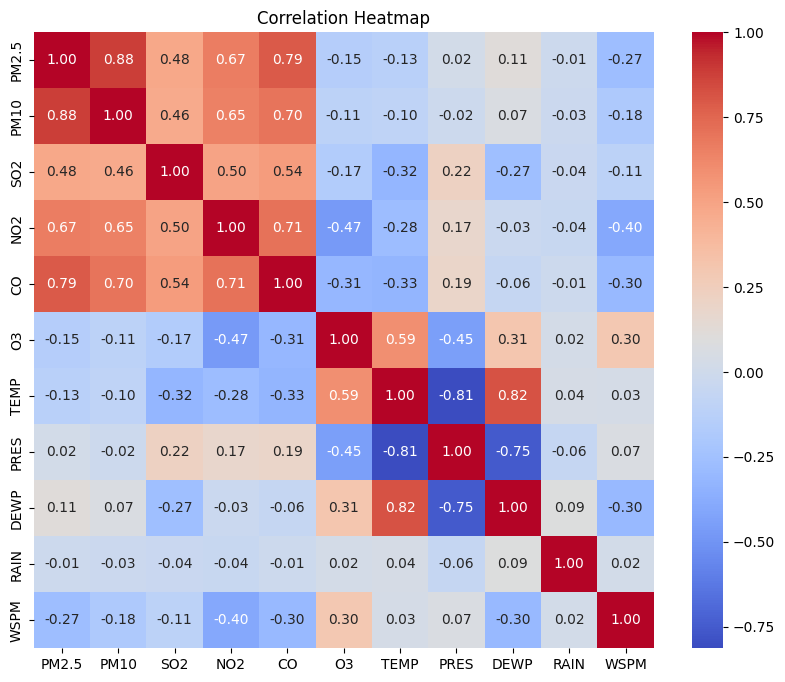

In [ ]:
numeric_cols = [
    "PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
    "TEMP", "PRES", "DEWP", "RAIN", "WSPM"
]

corr_matrix = combined_df[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

## 📌 Key Insights

- PM2.5 strongly correlates with PM10 and CO
- Pollution varies across stations
- Wind speed reduces pollution levels
- Data shows frequent pollution spikes
